In [1]:
import torch
import torchvision.transforms as T
import os
import numpy as np
import h5py
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split,Subset
from scipy import stats



import random
from sklearn.model_selection import KFold


from preprocess_test import get_data,get_full_data,DatasetInWindow,DatasetInWindowRescaled,rescale_data

In [2]:
# Functions

def select_random_windows(image, window_size, num_windows):
    windows = []
    nx, ny = image.shape
    while len(windows) < num_windows:
        x = random.randint(0, nx - window_size)
        y = random.randint(0, ny - window_size)
        window = image[x:x + window_size, y:y + window_size]
        if np.mean(window == 0) < 0.2:  # Less than 20% black pixels
            windows.append((x, y))
    return windows

def load_specific_window(x,y,window_size,dataset):
    get_data(rootdir, cat, SFs, x, y, window_size,augment=False)
    dataset = torch.load(os.path.join(rootdir, f'{cat}_data.pt'))
    return dataset

def load_data(window_size,dataset):
    sufficient_data = False
    while not sufficient_data:
        x = random.randint(46, 302 - window_size - 1)
        y = random.randint(127, 383- window_size - 1)
        get_data(rootdir, cat, SFs, x, y, window_size,augment=False)
        dataset = torch.load(os.path.join(rootdir, f'{cat}_data.pt'))
        
        # Check if dataset has sufficient data
        if len(dataset['images']) >= (val_size + test_size + 1):
            sufficient_data = True
        else:
            print(f"Insufficient data for window size {window_size}, reloading...")
    
    return dataset

# Custom Dataset class

class CustomDatasetFeature(Dataset):
    def __init__(self, dataset, TFvalues, SFvalues, device,feature):
        self.dataset = dataset.copy()
        self.TFvalues = TFvalues.detach().clone()
        self.SFvalues = SFvalues.detach().clone()
        self.device = device
        self.feature=feature

    def __len__(self):
        return len(self.dataset['images'])

    def __getitem__(self, idx):
        img = self.dataset['images'][idx].float().to(self.device)
        if self.feature=='DIR' or self.feature=='OR':
            speed = self.dataset['OR'][idx]*np.pi/100
        elif self.feature=='SF':
            speed = self.SFvalues[self.dataset['SF'][idx]-1]
        elif self.feature=='TF':
            speed = self.TFvalues[self.dataset['TF'][idx]]
        else:
            speed = self.TFvalues[self.dataset['TF'][idx]] / self.SFvalues[self.dataset['SF'][idx] - 1]


        return {'images': img, 'speed': speed.to(self.device)}


# Define the model
class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch['images'], batch['speed']
        out = self(images)
        loss = F.mse_loss(out, labels)
        return loss
    
    def validation_step(self, batch):
        images, labels = batch['images'], batch['speed']
        out = self(images)
        loss = F.mse_loss(out, labels)
        return {'val_loss': loss.detach()}
    
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        return {'val_loss': epoch_loss.item()}
    
    def epoch_end(self, epoch, result):
        print(f"Epoch [{epoch}], train_loss: {result['train_loss']:.4f}, val_loss: {result['val_loss']:.4f}")

class NetSmall(ImageClassificationBase):
    def __init__(self):
        super(NetSmall, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))  # Adaptive pooling layer
        self.fc1 = nn.Linear(16, 120)  # Fully connected layer 1
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class Net(ImageClassificationBase):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))  # Adaptive pooling layer
        self.fc1 = nn.Linear(16, 120)  # Fully connected layer 1
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def weights_init_uniform_rule(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        n = m.in_features
        y = 1.0 / np.sqrt(n)
        m.weight.data.uniform_(-y, y)
        m.bias.data.fill_(0)

# Evaluation function
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

# Training function
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []

    K_low=0
    K_High=0
    Loss=100
    for epoch in range(epochs):
#         if Loss>60 and K_High:
#             learning_rate=0.01
#         else:
        learning_rate=lr
        optimizer = opt_func(model.parameters(), learning_rate)
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        Loss_New=result['train_loss']
        model.epoch_end(epoch, result)
        history.append(result)
        if np.abs(Loss-Loss_New)<0.1:
            K_low=K_low+1
        else:
            K_low=0

        if K_low>10 and Loss<0.5:
            break
        Loss=Loss_New
    return history

def run_kfold_cross_validation(dataset,device,feature, k=10,batch_size=32,num_epochs=32,randstate=42,learning_rate=0.001,control=0):
    TFvalues = torch.tensor([0.38, 0.88, 1.24, 1.53, 2, 2.78, 3.26, 3.85, 5.37])
    SFvalues = torch.tensor([0.15, 0.29, 0.5, 0.9, 1.65])
    if control==1:
        shuffled_data = dataset.copy()
        if feature=='speed':
            np.random.shuffle(shuffled_data['TF'])
        else:
            np.random.shuffle(shuffled_data[feature])
        data_to_use=shuffled_data
    else:
        data_to_use=dataset.copy()

    data = CustomDatasetFeature(data_to_use, TFvalues, SFvalues, device,feature)
    
    kf = KFold(n_splits=k, shuffle=True, random_state=randstate)
    accuracies = []

    for fold, (train_index, val_index) in enumerate(kf.split(data)):
        train_data = Subset(data, train_index)
        val_data = Subset(data, val_index)
        
        train_loader = DataLoader(train_data, batch_size, shuffle=True)
        val_loader = DataLoader(val_data, batch_size)
        
            # Define model and optimizer
        if window_size<20:
            model=NetSmall().to(device)
        else:
            model = Net().to(device)

        model.apply(weights_init_uniform_rule)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        for epoch in range(num_epochs):
            model.train()
            for batch in train_loader:
                images, labels = batch['images'], batch['speed']
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            # Evaluate after each epoch and print the result
            result = evaluate(model, val_loader)
            result['train_loss'] = loss.item()
            model.epoch_end(epoch, result)
        
        accuracy = evaluate(model, val_loader)
        accuracies.append(accuracy)

    return accuracies


In [3]:

# Define the dimensions for categories
cat_dims = {}
cat_dims['IJXX'] = (330, 510)
cat_dims['IJA2'] = (330, 498)
cat_dims['IJB2'] = (348, 510)

region = {}
region['IJXX'] = (30,250,30,250)
region['IJA2'] = (20,280,50,300)
region['IJB2'] = (20,300,50,250)



# Define transform
transform = T.Compose([T.ToTensor()])




In [4]:
# Experiment setup

rootdir = os.path.expanduser("/Users/jonathantouboul/Dropbox/Machine_Learning_Vision/DATA/")
SFs = 4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


TFvalues = torch.tensor([0.38, 0.88, 1.24, 1.53, 2, 2.78, 3.26, 3.85, 5.37])
SFvalues = torch.tensor([0.15, 0.29, 0.5, 0.9, 1.65])

batch_size = 32
val_size = 900
test_size = 900
cats = ['IJXX', 'IJA2', 'IJB2']
feature='TF'
all_accuracies = {}
all_baseline_accuracies = {}
folds=10
max_epoch = 200
learning_rate = 10e-4
randstate=42
window_size=100

In [5]:
cat='IJXX'
dataset=get_full_data(rootdir, cat, SFs)

100%|█████████████████████████████████████████████| 4/4 [00:45<00:00, 11.35s/it]


In [6]:
region['IJXX'][0]

30

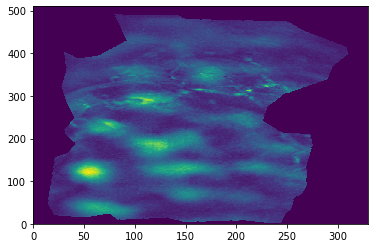

In [7]:
plt.pcolor(dataset['images'][100].squeeze())

In [8]:
region['IJXX'][0]

30

In [11]:
ALL_CATS=0
if ALL_CATS==1:
    for cat in cats:
        dataset_base=get_full_data(rootdir, cat, SFs)
    #     dataset=DatasetInWindow(dataset_base,region[cat][0],region[cat][2],200)
        dataset_Normalized =DatasetInWindowRescaled(dataset_base,region[cat][0],region[cat][2],200)
        all_accuracies[cat]=run_kfold_cross_validation(dataset_Normalized,device,feature,folds,batch_size,max_epoch,randstate,learning_rate,0)
    #     all_baseline_accuracies[cat]=run_kfold_cross_validation(dataset_Normalized,device,feature,folds,batch_size,max_epoch,randstate,learning_rate,1)
else:
    cat='IJXX'
    dataset_Normalized =DatasetInWindowRescaled(dataset,region[cat][0],region[cat][2],200)
    all_accuracies[cat]=run_kfold_cross_validation(dataset_Normalized,device,feature,folds,batch_size,max_epoch,randstate,learning_rate,0)



Epoch [0], train_loss: 1.8519, val_loss: 1.7746
Epoch [1], train_loss: 2.2878, val_loss: 1.6969
Epoch [2], train_loss: 2.4166, val_loss: 1.6582
Epoch [3], train_loss: 0.9441, val_loss: 1.6358
Epoch [4], train_loss: 1.0228, val_loss: 1.6146
Epoch [5], train_loss: 2.3087, val_loss: 1.6070
Epoch [6], train_loss: 1.8188, val_loss: 1.6532


KeyboardInterrupt: 

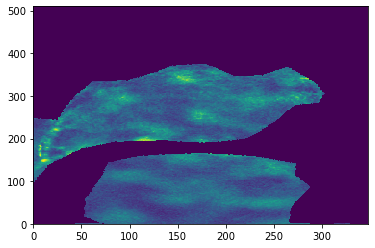

In [23]:
plt.pcolor(dataset['images'][100].squeeze())

In [ ]:
all_accuracies_baseline

In [6]:
model=Net().to(device)

In [7]:
model

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=16, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=1, bias=True)
)

In [13]:

data = CustomDatasetFeature(dataset, TFvalues, SFvalues, device,feature)

In [15]:
traindata=Subset(data,1)

In [20]:
traindata
train_loader = DataLoader(traindata, 10)

In [24]:
y=model(dataset['images'][100])

RuntimeError: expected scalar type Double but found Float

In [21]:
from torchviz import make_dot

make_dot(train_loader, params=dict(list(model.named_parameters()))).render("rnn_torchviz", format="png")

AttributeError: 'DataLoader' object has no attribute 'size'

In [9]:
import hiddenlayer as hl

transforms = [ hl.transforms.Prune('Constant') ] # Removes Constant nodes from graph.

graph = hl.build_graph(model, batch.text, transforms=transforms)
graph.theme = hl.graph.THEMES['blue'].copy()
graph.save('rnn_hiddenlayer', format='png')

ModuleNotFoundError: No module named 'hiddenlayer'